# Crop Disease Detection — MobileNetV2 Transfer Learning

Trains an image classifier on crop leaf photos using transfer learning on MobileNetV2,
then exports a `.h5` file for use in the Django `detection` app.

**Before running:** place your dataset in a `dataset/` folder next to this notebook,
organized as `dataset/<ClassName>/<image files>` (one subfolder per crop-disease class,
e.g. `dataset/Tomato___Early_blight/`, `dataset/Tomato___healthy/`).

## 1. Imports

In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU available: []


## 2. Config

In [8]:
DATASET_DIR = "dataset"          # path to your dataset folder (one subfolder per class)
IMAGE_SIZE = (224, 224)          # MobileNetV2 default input size
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2
INITIAL_EPOCHS = 2              # training with the base model frozen
FINE_TUNE_EPOCHS = 1             # additional training with top layers unfrozen
FINE_TUNE_AT = 100               # unfreeze layers from this index onward in MobileNetV2
OUTPUT_MODEL_PATH = "crop_disease_mobilenet.h5"
OUTPUT_LABELS_PATH = "class_labels.json"

## 3. Data generators

Uses `preprocess_input` (MobileNetV2's own normalization) rather than a plain `rescale=1./255`, since that's what the base model was trained with.

In [5]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=VALIDATION_SPLIT,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.15,
)

train_gen = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
)

val_gen = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
)

num_classes = train_gen.num_classes
print(f"Found {num_classes} classes:")
print(train_gen.class_indices)

Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.
Found 15 classes:
{'Pepper__bell___Bacterial_spot': 0, 'Pepper__bell___healthy': 1, 'Potato___Early_blight': 2, 'Potato___Late_blight': 3, 'Potato___healthy': 4, 'Tomato_Bacterial_spot': 5, 'Tomato_Early_blight': 6, 'Tomato_Late_blight': 7, 'Tomato_Leaf_Mold': 8, 'Tomato_Septoria_leaf_spot': 9, 'Tomato_Spider_mites_Two_spotted_spider_mite': 10, 'Tomato__Target_Spot': 11, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 12, 'Tomato__Tomato_mosaic_virus': 13, 'Tomato_healthy': 14}


## 4. Preview a few training images

Sanity check — confirm the images and labels look right before spending time training.

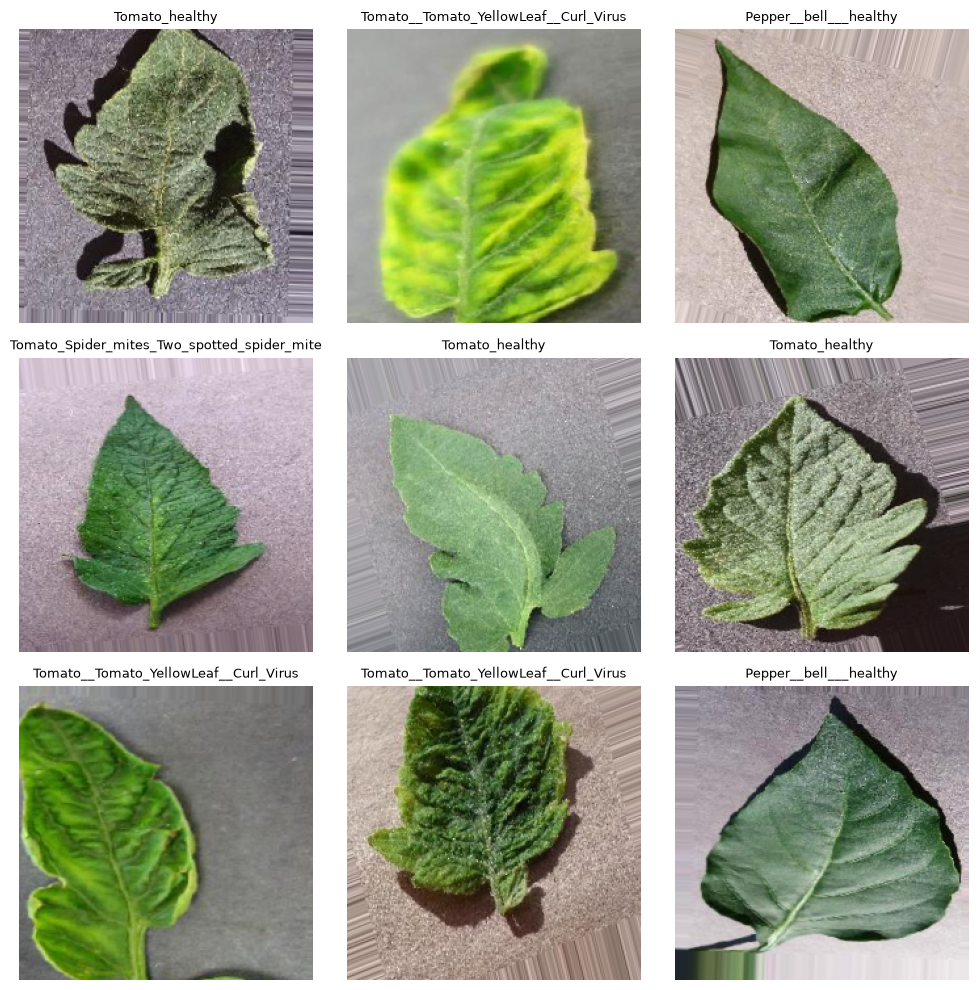

In [6]:
images, labels = next(train_gen)
class_names = {v: k for k, v in train_gen.class_indices.items()}

plt.figure(figsize=(10, 10))
for i in range(min(9, len(images))):
    plt.subplot(3, 3, i + 1)
    # undo preprocess_input's normalization just for display
    display_img = (images[i] - images[i].min()) / (images[i].max() - images[i].min())
    plt.imshow(display_img)
    label_idx = int(np.argmax(labels[i]))
    plt.title(class_names[label_idx], fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

## 5. Build the model

MobileNetV2 pretrained on ImageNet, frozen, with a new classification head on top.

In [9]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMAGE_SIZE, 3),
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,423,887 (9.25 MB)

 Trainable params: 165,903 (648.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 6. Train the classification head

Base model stays frozen here — only the new top layers learn.

In [10]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ModelCheckpoint("best_head_only.h5", monitor="val_accuracy", save_best_only=True),
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=INITIAL_EPOCHS,
    callbacks=callbacks,
)

Epoch 1/2
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7450 - loss: 0.8048

517/517 ━━━━━━━━━━━━━━━━━━━━ 1319s 3s/step - accuracy: 0.7450 - loss: 0.8048 - val_accuracy: 0.8775 - val_loss: 0.3883
Epoch 2/2
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8520 - loss: 0.4487

517/517 ━━━━━━━━━━━━━━━━━━━━ 1019s 2s/step - accuracy: 0.8520 - loss: 0.4487 - val_accuracy: 0.8792 - val_loss: 0.3649


## 7. Fine-tune

Unfreeze the top layers of MobileNetV2 and continue training at a much lower learning rate, so the pretrained weights adjust slightly to crop-disease features instead of being overwritten.

In [11]:
base_model.trainable = True

for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

fine_tune_callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ModelCheckpoint("best_fine_tuned.h5", monitor="val_accuracy", save_best_only=True),
]

history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=fine_tune_callbacks,
)

517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7581 - loss: 0.7705

517/517 ━━━━━━━━━━━━━━━━━━━━ 1388s 3s/step - accuracy: 0.7581 - loss: 0.7705 - val_accuracy: 0.8731 - val_loss: 0.3679


## 8. Plot training curves

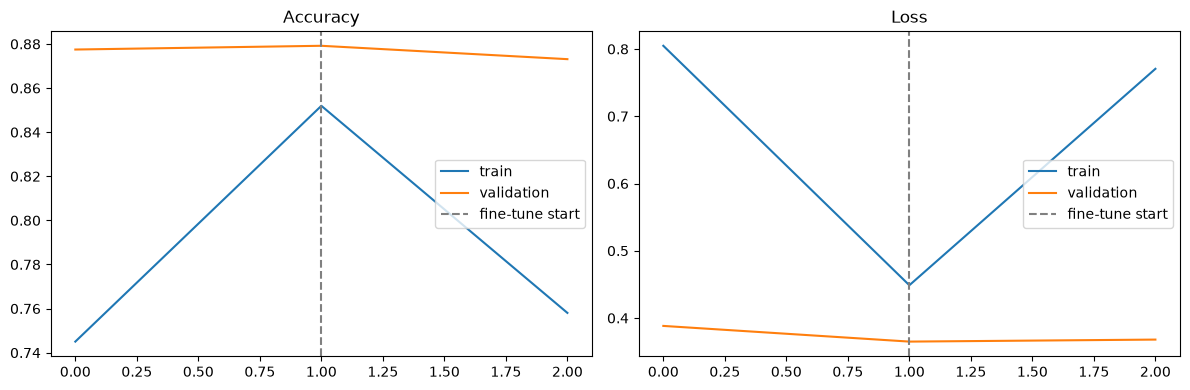

In [12]:
def combine_histories(h1, h2, key):
    return h1.history[key] + h2.history[key]

acc = combine_histories(history, history_fine, "accuracy")
val_acc = combine_histories(history, history_fine, "val_accuracy")
loss = combine_histories(history, history_fine, "loss")
val_loss = combine_histories(history, history_fine, "val_loss")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(acc, label="train")
axes[0].plot(val_acc, label="validation")
axes[0].axvline(INITIAL_EPOCHS - 1, color="gray", linestyle="--", label="fine-tune start")
axes[0].set_title("Accuracy")
axes[0].legend()

axes[1].plot(loss, label="train")
axes[1].plot(val_loss, label="validation")
axes[1].axvline(INITIAL_EPOCHS - 1, color="gray", linestyle="--", label="fine-tune start")
axes[1].set_title("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Evaluate on the validation set

In [13]:
val_loss_final, val_acc_final = model.evaluate(val_gen)
print(f"Validation accuracy: {val_acc_final:.2%}")
print(f"Validation loss: {val_loss_final:.4f}")

129/129 ━━━━━━━━━━━━━━━━━━━━ 224s 2s/step - accuracy: 0.8763 - loss: 0.3673
Validation accuracy: 87.63%
Validation loss: 0.3673


## 10. Export the model and class labels

`crop_disease_mobilenet.h5` goes into `detection/ml/` in the Django project.

`class_labels.json` is a reference file — copy its contents into `CLASS_LABELS` in
`detection/ml/model_loader.py`, ordered by index (0, 1, 2, ...), since that's the
order the model's output layer corresponds to.

In [14]:
model.save(OUTPUT_MODEL_PATH)
print(f"Model saved to {OUTPUT_MODEL_PATH}")

# class_indices maps label -> index; invert and sort by index for CLASS_LABELS order
index_to_label = {v: k for k, v in train_gen.class_indices.items()}
ordered_labels = [index_to_label[i] for i in range(num_classes)]

with open(OUTPUT_LABELS_PATH, "w") as f:
    json.dump(ordered_labels, f, indent=2)

print(f"Class labels saved to {OUTPUT_LABELS_PATH}")
print("\nCLASS_LABELS = [")
for label in ordered_labels:
    print(f'    "{label}",')
print("]")

Model saved to crop_disease_mobilenet.h5
Class labels saved to class_labels.json

CLASS_LABELS = [
    "Pepper__bell___Bacterial_spot",
    "Pepper__bell___healthy",
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy",
    "Tomato_Bacterial_spot",
    "Tomato_Early_blight",
    "Tomato_Late_blight",
    "Tomato_Leaf_Mold",
    "Tomato_Septoria_leaf_spot",
    "Tomato_Spider_mites_Two_spotted_spider_mite",
    "Tomato__Target_Spot",
    "Tomato__Tomato_YellowLeaf__Curl_Virus",
    "Tomato__Tomato_mosaic_virus",
    "Tomato_healthy",
]


## 11. Quick sanity check on a single image

Optional — load the saved model back and run one prediction to confirm the whole
pipeline (load -> preprocess -> predict -> label) works before wiring it into Django.

In [ ]:
from tensorflow.keras.preprocessing import image as keras_image

def predict_single_image(img_path, model, labels):
    img = keras_image.load_img(img_path, target_size=IMAGE_SIZE)
    arr = keras_image.img_to_array(img)
    arr = preprocess_input(arr)
    arr = np.expand_dims(arr, axis=0)

    preds = model.predict(arr)[0]
    idx = int(np.argmax(preds))
    return labels[idx], float(preds[idx])

# Example usage -- replace with a real path to one of your dataset images:
# label, confidence = predict_single_image("dataset/Tomato___Early_blight/some_image.jpg", model, ordered_labels)
# print(f"Predicted: {label} ({confidence:.2%})")